In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

#  ****Basic Linear Regression****

First 5 rows:
    StudyHours  ExamScore
0    4.370861  48.030083
1    9.556429  91.864700
2    7.587945  72.713268
3    6.387926  60.985819
4    2.404168  19.244900

Slope (coefficient): 8.846
Intercept: 5.772
MSE: 19.908
RMSE: 4.462
R² Score: 0.942


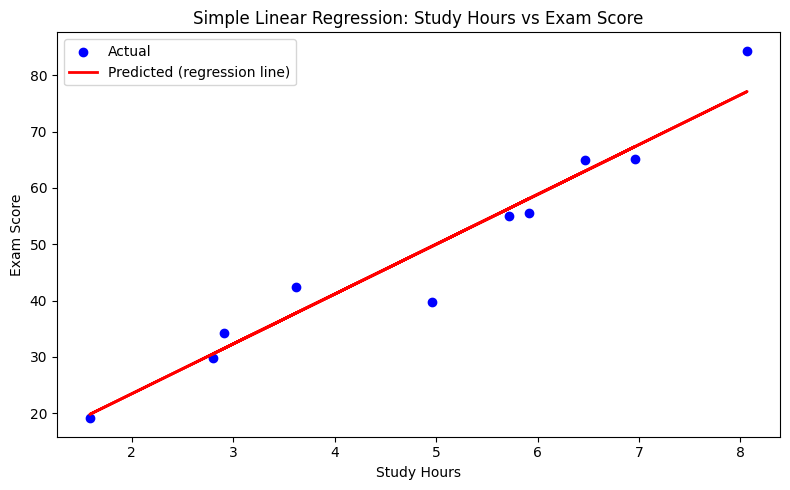


Predicted exam score for 6.5 study hours: 63.27


In [2]:
"""
Simple Linear Regression Model
Task: One feature (Study Hours) -> One target (Exam Score)
Library: scikit-learn
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create / load dataset
# Replace this block with pd.read_csv("your_file.csv") if you have real data
np.random.seed(42)
hours = np.random.uniform(1, 10, 50)
scores = 5 + 9 * hours + np.random.normal(0, 5, 50)  # y = mx + c + noise

df = pd.DataFrame({"StudyHours": hours, "ExamScore": scores})
print("First 5 rows:\n", df.head())

# 2. Split into feature (X) and target (y)
X = df[["StudyHours"]]   # must be 2D for sklearn
y = df["ExamScore"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nSlope (coefficient): {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# 7. Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted (regression line)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression: Study Hours vs Exam Score")
plt.legend()
plt.tight_layout()
plt.savefig("regression_plot.png")
plt.show()

# 8. Predict a new value (example usage)
new_hours = pd.DataFrame({"StudyHours": [6.5]})
predicted_score = model.predict(new_hours)
print(f"\nPredicted exam score for 6.5 study hours: {predicted_score[0]:.2f}")